In [ ]:
# ── MobileNetV2 학습 노트북 (지표 2용: 완성 이미지 분류) ──────────────────
import os
import json
import random
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from google.colab import drive

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 디바이스: {device}")


✅ 디바이스: cuda


In [ ]:
# ── 하이퍼파라미터 ────────────────────────────────────────────────────────────
CLASSES = [
    'hot air balloon', 'motorbike', 'sailboat', 'airplane', 'helicopter',
    'submarine', 'canoe', 'bus', 'car', 'train'
]
NUM_CLASSES       = len(CLASSES)
SAMPLES_PER_CLASS = 10000
TRAIN_RATIO       = 0.70
VAL_RATIO         = 0.15
TEST_RATIO        = 0.15
BATCH_SIZE        = 128
NUM_EPOCHS        = 15
LEARNING_RATE     = 0.001
WEIGHT_DECAY      = 1e-4
DROPOUT_RATE      = 0.3
IMG_SIZE          = 256

print(f"✅ 하이퍼파라미터 설정 완료!")
print(f"   클래스: {NUM_CLASSES}개 / 클래스당 {SAMPLES_PER_CLASS:,}장 / {NUM_EPOCHS}에폭")


✅ 하이퍼파라미터 설정 완료!
   클래스: 10개 / 클래스당 10,000장 / 15에폭


In [ ]:
# ── Google Drive 마운트 ───────────────────────────────────────────────────────
drive.mount('/content/drive')

DRIVE_PATH      = '/content/drive/MyDrive/딥러닝'
os.makedirs(DRIVE_PATH, exist_ok=True)

BEST_MODEL_PATH = os.path.join(DRIVE_PATH, 'best_model_mobilenetv2.pth')
HISTORY_PATH    = os.path.join(DRIVE_PATH, 'best_model_mobilenetv2_history.json')

print(f"✅ Drive 마운트 완료")
print(f"   모델 저장 경로: {BEST_MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive 마운트 완료
   모델 저장 경로: /content/drive/MyDrive/딥러닝/best_model_mobilenetv2.pth


In [ ]:
# ── 데이터 다운로드 ───────────────────────────────────────────────────────────
os.makedirs('quickdraw_data', exist_ok=True)
BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/simplified"

print("🔽 QuickDraw 데이터 다운로드...")
for class_name in tqdm(CLASSES, desc="다운로드"):
    filepath = f"quickdraw_data/{class_name.replace(' ', '_')}.ndjson"
    if os.path.exists(filepath):
        print(f"  ✓ {class_name}: 존재")
        continue
    url = f"{BASE_URL}/{class_name.replace(' ', '%20')}.ndjson"
    os.system(f"wget -q '{url}' -O '{filepath}'")
    print(f"  ✓ {class_name}: 완료")

print("\n✅ 다운로드 완료!")


🔽 QuickDraw 데이터 다운로드...


다운로드:   0%|          | 0/10 [00:00<?, ?it/s]

  ✓ hot air balloon: 존재
  ✓ motorbike: 존재
  ✓ sailboat: 존재
  ✓ airplane: 존재
  ✓ helicopter: 존재
  ✓ submarine: 존재
  ✓ canoe: 존재
  ✓ bus: 존재
  ✓ car: 존재
  ✓ train: 존재

✅ 다운로드 완료!


In [ ]:
# ── 전처리 함수 ───────────────────────────────────────────────────────────────
def convert_raw_to_simplified(raw_strokes):
    x_list = [stroke[0] for stroke in raw_strokes]
    y_list = [stroke[1] for stroke in raw_strokes]
    return x_list, y_list

def render_strokes_to_image(x_list, y_list, img_size=256):
    """모든 획을 한 번에 렌더링 (완성 이미지)"""
    img  = Image.new('L', (img_size, img_size), 255)
    draw = ImageDraw.Draw(img)

    all_x, all_y = [], []
    for i in range(len(x_list)):
        all_x.extend(x_list[i])
        all_y.extend(y_list[i])

    if len(all_x) == 0:
        return img

    min_x, max_x = min(all_x), max(all_x)
    min_y, max_y = min(all_y), max(all_y)
    range_x = max(max_x - min_x, 1)
    range_y = max(max_y - min_y, 1)

    padding = 20
    scale   = (img_size - 2 * padding) / max(range_x, range_y)

    for i in range(len(x_list)):
        x_coords, y_coords = x_list[i], y_list[i]
        for j in range(len(x_coords) - 1):
            x1 = int((x_coords[j]   - min_x) * scale + padding)
            y1 = int((y_coords[j]   - min_y) * scale + padding)
            x2 = int((x_coords[j+1] - min_x) * scale + padding)
            y2 = int((y_coords[j+1] - min_y) * scale + padding)
            draw.line([(x1, y1), (x2, y2)], fill=0, width=2)

    return img

print("✅ 전처리 함수 정의 완료")


✅ 전처리 함수 정의 완료


In [ ]:
# ── 데이터 로딩 및 분할 ───────────────────────────────────────────────────────
def load_and_split_data():
    all_data = []
    print("📖 데이터 로딩...")
    for label_idx, class_name in enumerate(tqdm(CLASSES, desc="로딩")):
        filepath = f"quickdraw_data/{class_name.replace(' ', '_')}.ndjson"
        class_samples = []
        with open(filepath, 'r') as f:
            for line in f:
                sample = json.loads(line)
                if sample.get('recognized', False):
                    class_samples.append({
                        'strokes':    sample['drawing'],
                        'label':      label_idx,
                        'class_name': class_name
                    })
                if len(class_samples) >= SAMPLES_PER_CLASS:
                    break
        all_data.extend(class_samples)
        print(f"  ✓ {class_name}: {len(class_samples):,}개")

    random.shuffle(all_data)
    total     = len(all_data)
    train_end = int(total * TRAIN_RATIO)
    val_end   = train_end + int(total * VAL_RATIO)

    return all_data[:train_end], all_data[train_end:val_end], all_data[val_end:]

train_data, val_data, test_data = load_and_split_data()
print(f"\n✅ 분할 완료! Train: {len(train_data):,} / Val: {len(val_data):,} / Test: {len(test_data):,}")


📖 데이터 로딩...


로딩:   0%|          | 0/10 [00:00<?, ?it/s]

  ✓ hot air balloon: 10,000개
  ✓ motorbike: 10,000개
  ✓ sailboat: 10,000개
  ✓ airplane: 10,000개
  ✓ helicopter: 10,000개
  ✓ submarine: 10,000개
  ✓ canoe: 10,000개
  ✓ bus: 10,000개
  ✓ car: 10,000개
  ✓ train: 10,000개

✅ 분할 완료! Train: 70,000 / Val: 15,000 / Test: 15,000


In [ ]:
# ── Dataset & DataLoader ──────────────────────────────────────────────────────
class QuickDrawDataset(Dataset):
    """완성 이미지만 사용 (use_partial_strokes 없음)"""
    def __init__(self, data, transform=None):
        self.data      = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample     = self.data[idx]
        x_strokes, y_strokes = convert_raw_to_simplified(sample['strokes'])
        img        = render_strokes_to_image(x_strokes, y_strokes, IMG_SIZE)
        img        = img.convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, sample['label']

train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(QuickDrawDataset(train_data, train_transform), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(QuickDrawDataset(val_data,   eval_transform),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(QuickDrawDataset(test_data,  eval_transform),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ DataLoader 완료! 배치: {BATCH_SIZE} / Train 배치 수: {len(train_loader):,}")


✅ DataLoader 완료! 배치: 128 / Train 배치 수: 547


In [ ]:
# ── 모델 정의 ─────────────────────────────────────────────────────────────────
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ 모델 생성 완료! 파라미터: {total_params:,}개")


✅ 모델 생성 완료! 파라미터: 2,236,682개


In [ ]:
# ── 학습 함수 ─────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc="학습")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{100.*correct/total:.2f}%'})
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="평가"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

print("✅ 학습 함수 정의 완료")


✅ 학습 함수 정의 완료


In [ ]:
# ── 학습 실행 ─────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history     = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

# Drive에 저장된 모델 있으면 스킵
if os.path.exists(BEST_MODEL_PATH):
    print("✅ Drive에서 저장된 모델 발견! 학습 스킵")
    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    model.to(device)
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, 'r') as f:
            history = json.load(f)
        best_val_acc = max(history['val_acc']) if history['val_acc'] else 0
        print(f"   최고 Val Acc: {best_val_acc:.2f}%")
else:
    print("🚀 학습 시작!")
    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\n📚 Epoch {epoch}/{NUM_EPOCHS}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  Train: {train_loss:.4f} | {train_acc:.2f}%")
        print(f"  Val:   {val_loss:.4f} | {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"  ⭐ 최고 성능! ({val_acc:.2f}%) → Drive 저장")

        scheduler.step(val_loss)

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"\n✅ 학습 완료! 최고 Val Acc: {best_val_acc:.2f}%")
    model.load_state_dict(torch.load(BEST_MODEL_PATH))


🚀 학습 시작!

📚 Epoch 1/15


학습:   0%|          | 0/547 [00:00<?, ?it/s]

평가:   0%|          | 0/118 [00:00<?, ?it/s]

  Train: 0.1970 | 93.70%
  Val:   0.1191 | 96.21%
  ⭐ 최고 성능! (96.21%) → Drive 저장

📚 Epoch 2/15


학습:   0%|          | 0/547 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6a607a3ec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e6a607a3ec0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      if w.is_alive(): 
              ^ ^^^^^^^^^^^^^^^^^^
  Fil

  Train: 0.0493 | 98.33%
  Val:   0.0730 | 97.67%

📚 Epoch 15/15


학습:   0%|          | 0/547 [00:00<?, ?it/s]

평가:   0%|          | 0/118 [00:00<?, ?it/s]

  Train: 0.0377 | 98.71%
  Val:   0.0681 | 97.98%
  ⭐ 최고 성능! (97.98%) → Drive 저장

✅ 학습 완료! 최고 Val Acc: 97.98%


In [ ]:
# ── 테스트 ────────────────────────────────────────────────────────────────────
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\n📊 최종 테스트 결과")
print(f"   Test Acc : {test_acc:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")

# 클래스별 정확도
model.eval()
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted   = model(images).max(1)
        for p, t in zip(predicted, labels):
            class_total[t.item()]   += 1
            if p.item() == t.item():
                class_correct[t.item()] += 1

print("\n클래스별 정확도:")
for i, cls in enumerate(CLASSES):
    acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"  {cls:<20}: {acc:.1f}%")


평가:   0%|          | 0/118 [00:00<?, ?it/s]


📊 최종 테스트 결과
   Test Acc : 97.86%
   Test Loss: 0.0687

클래스별 정확도:
  hot air balloon     : 99.6%
  motorbike           : 99.1%
  sailboat            : 98.2%
  airplane            : 98.9%
  helicopter          : 98.8%
  submarine           : 97.1%
  canoe               : 98.0%
  bus                 : 96.1%
  car                 : 96.3%
  train               : 96.5%


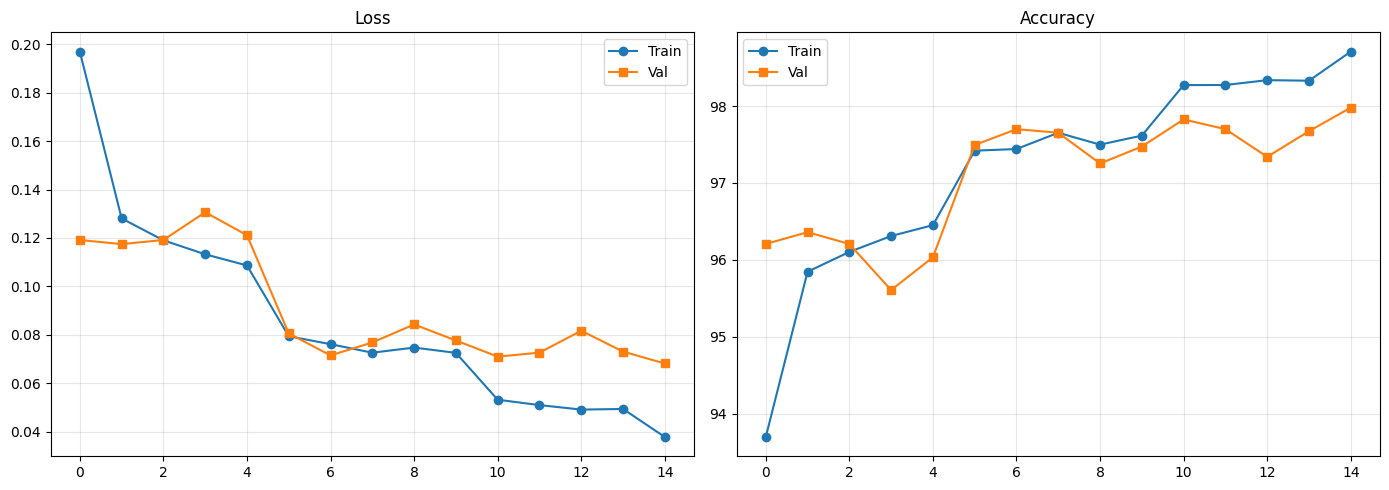

In [ ]:
# ── 학습 결과 시각화 ──────────────────────────────────────────────────────────
if history['train_acc']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], label='Train', marker='o')
    axes[0].plot(history['val_loss'],   label='Val',   marker='s')
    axes[0].set_title('Loss');  axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history['train_acc'],  label='Train', marker='o')
    axes[1].plot(history['val_acc'],    label='Val',   marker='s')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
